____
# COMPUTE GRADIENT, INTERPOLATE AND ROTATE SWOT DATA ON COLOC POINTS

In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, images_dir
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo

crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

In [2]:
images_dir

'/Users/mdemol/ownCloud/PhD/images/med_images'

_______
# Data

In [3]:
dfs = browse_swot_250().reset_index()
drifters_sources = "all_med_variational_10min_v0.nc"
df = pd.read_csv(
    os.path.join(zarr_dir, "drifters_" + drifters_sources.replace(".nc", ".csv"))
)  # .drop(columns='Unnamed: 0')

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_38453/1524825581.py:3: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(zarr_dir, 'drifters_'+drifters_sources.replace('.nc', '.csv')))#.drop(columns='Unnamed: 0')


__________
# SWOT

In [4]:
# get grid orientation and metrics
def add_grid_metrics(ds):
    """add grid spatial metrics"""

    geod = Geod(ellps="WGS84")

    lon, lat = ds.longitude, ds.latitude
    dims = lon.dims

    # d/dx where x is cross-track
    az12, az21, dx = geod.inv(
        lon,
        lat,
        lon.shift(num_pixels=-1),
        lat.shift(num_pixels=-1),
    )

    ds = ds.assign_coords(dx=(dims, dx), phi=(dims, az12 * np.pi / 180))

    ds["dx"] = ds["dx"].ffill("num_pixels").where(ds["duacs_editing_flag"] < 5)

    # phi_lon is cross-track direction from north
    ds["phix"] = ds["phi"].ffill("num_pixels").where(ds["duacs_editing_flag"] < 5)

    # d/dy where y is along-track
    az12, az21, dy = geod.inv(
        lon,
        lat,
        lon.shift(num_lines=-1),
        lat.shift(num_lines=-1),
    )

    # phiy is along-track direction from north
    ds = ds.assign_coords(phi=(dims, az12 * np.pi / 180))
    ds["phiy"] = ds["phi"].ffill("num_pixels").where(ds["duacs_editing_flag"] < 5)

    ds = ds.assign_coords(dy=(dims, dy))

    ds["dy"] = ds["dy"].ffill("num_lines").where(ds["duacs_editing_flag"] < 5)
    ds["phi"] = ds["phix"]
    return ds

In [5]:
cycle = 500
swath = 3

dss = xr.open_dataset(
    dfs.where((dfs.pass_number == swath) & (dfs.cycle_number == cycle))
    .dropna()
    .file.values[0]
)
dss = add_grid_metrics(dss)
dss

/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


<xarray.Dataset> Size: 553MB
Dimensions:                                  (num_lines: 4161, num_pixels: 519)
Coordinates:
    latitude                                 (num_lines, num_pixels) float64 17MB ...
    longitude                                (num_lines, num_pixels) float64 17MB ...
    dx                                       (num_lines, num_pixels) float64 17MB ...
    phi                                      (num_lines, num_pixels) float64 17MB ...
    dy                                       (num_lines, num_pixels) float64 17MB ...
Dimensions without coordinates: num_lines, num_pixels
Data variables: (12/40)
    ancillary_surface_classification_flag    (num_lines, num_pixels) float32 9MB ...
    cross_track_distance                     (num_lines, num_pixels) float32 9MB ...
    cvl_cross_track_distance                 (num_lines, num_pixels) float32 9MB ...
    cvl_dac                                  (num_lines, num_pixels) float64 17MB ...
    cvl_distance_to_coast                    (num_lines, num_pixels) float64 17MB ...
    cvl_flag_val                             (num_lines, num_pixels) float32 9MB ...
    ...                                       ...
    ssh_karin_2_qual                         (num_lines, num_pixels) float64 17MB ...
    time                                     (num_lines) datetime64[ns] 33kB ...
    time_tai                                 (num_lines) datetime64[ns] 33kB ...
    version                                  (num_lines) |S7 29kB ...
    phix                                     (num_lines, num_pixels) float64 17MB ...
    phiy                                     (num_lines, num_pixels) float64 17MB ...
Attributes:
    latc:     39.39991
    lonc:     4.205744
    phi:      76.96918844368692

In [6]:
bbox = [2.7, 6.1, 36.6, 43.5]


def plot_swot(swath, cycle):
    if swath == 3:
        bbox = [2.7, 6.1, 36.6, 43.5]
        figsize = (18, 28)
    if swath == 16:
        bbox = [0.9, 3.7, 37.7, 41.25]
        figsize = (22, 24)

    dss = xr.open_dataset(
        dfs.where((dfs.pass_number == swath) & (dfs.cycle_number == cycle))
        .dropna()
        .file.values[0]
    )
    dss = add_grid_metrics(dss)

    fig = plt.figure(figsize=figsize)
    fig.patch.set_facecolor("white")  # no transparancy in png

    pad = 0.2
    ax = fig.add_subplot(331, projection=ccrs.Orthographic(4, 40))
    median = dss.duacs_ssha_karin_2_filtered.median()
    (dss.duacs_ssha_karin_2_filtered - median).plot(
        x="longitude",
        y="latitude",
        transform=crs,
        vmin=-0.2,
        vmax=0.2,
        cmap="RdBu_r",
        cbar_kwargs={"pad": pad},
    )
    ax.add_feature(
        cfeature.LAND,
    )
    ax.set_title("duacs_ssha_karin_2_filtered - median")
    ax.set_extent(bbox)
    gl = ax.gridlines(
        draw_labels=True,
    )

    ax = fig.add_subplot(332, projection=ccrs.Orthographic(4, 40))
    median = dss.duacs_ssha_karin_2_filtered.median()
    (dss.duacs_ssha_karin_2_calibrated - median).plot(
        x="longitude",
        y="latitude",
        transform=crs,
        vmin=-0.2,
        vmax=0.2,
        cmap="RdBu_r",
        cbar_kwargs={"pad": pad},
    )
    ax.set_title("duacs_ssha_karin_2_calibrated - median")
    ax.add_feature(
        cfeature.LAND,
    )
    ax.set_extent(bbox)
    gl = ax.gridlines(
        draw_labels=True,
    )

    ax = fig.add_subplot(333, projection=ccrs.Orthographic(4, 40))
    (dss.duacs_ssha_karin_2_calibrated - dss.duacs_ssha_karin_2_filtered).plot(
        x="longitude",
        y="latitude",
        transform=crs,
        vmin=-0.02,
        vmax=0.02,
        cmap="RdBu_r",
        cbar_kwargs={"pad": pad},
    )
    ax.add_feature(
        cfeature.LAND,
    )
    ax.set_extent(bbox)
    gl = ax.gridlines(
        draw_labels=True,
    )

    ax = fig.add_subplot(334, projection=ccrs.Orthographic(4, 40))
    dss.cvl_ssha_reference.plot(
        x="longitude",
        y="latitude",
        transform=crs,
        vmin=-5,
        vmax=5,
        cbar_kwargs={"pad": pad},
    )
    ax.add_feature(
        cfeature.LAND,
    )
    ax.set_title("cvl_ssha_reference")
    ax.set_extent(bbox)
    gl = ax.gridlines(
        draw_labels=True,
    )

    ax = fig.add_subplot(335, projection=ccrs.Orthographic(4, 40))
    dss.cvl_mean_sea_surface_cnes_22_hybrid.plot(
        x="longitude", y="latitude", transform=crs, cbar_kwargs={"pad": pad}
    )
    ax.set_title("cvl_mean_sea_surface_cnes_22_hybrid")
    ax.add_feature(
        cfeature.LAND,
    )
    ax.set_extent(bbox)
    gl = ax.gridlines(
        draw_labels=True,
    )

    ax = fig.add_subplot(336, projection=ccrs.Orthographic(4, 40))
    dss.cvl_mean_dynamic_topography_cnes_cls_22.plot(
        x="longitude", y="latitude", transform=crs, cbar_kwargs={"pad": pad}
    )
    ax.set_title("cvl_mean_dynamic_topography_cnes_cls_22")
    ax.add_feature(
        cfeature.LAND,
    )
    ax.set_extent(bbox)
    gl = ax.gridlines(
        draw_labels=True,
    )

    ax = fig.add_subplot(337, projection=ccrs.Orthographic(4, 40))
    dss.cvl_dac.plot(
        x="longitude", y="latitude", transform=crs, cbar_kwargs={"pad": pad}
    )
    ax.add_feature(
        cfeature.LAND,
    )
    ax.set_title("cvl_dac")
    ax.set_extent(bbox)
    gl = ax.gridlines(
        draw_labels=True,
    )

    ax = fig.add_subplot(338, projection=ccrs.Orthographic(4, 40))
    dss.cvl_ocean_tide_fes_2022.plot(
        x="longitude", y="latitude", transform=crs, cbar_kwargs={"pad": pad}
    )
    ax.add_feature(
        cfeature.LAND,
    )
    ax.set_extent(bbox)
    ax.set_title("cvl_ocean_tide_fes_2022")
    gl = ax.gridlines(
        draw_labels=True,
    )

    fig.tight_layout()
    path = os.path.join(images_dir, "swot", f"swot_{swath}", f"{cycle}.png")
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)

In [7]:
for swath in [3, 16]:
    for cycle in (
        df.where(df.pass_number == swath).dropna().cycle_number.unique().astype(int)
    ):
        path = os.path.join(images_dir, "swot", f"swot_{swath}", f"{cycle}.png")
        if not os.path.isfile(path):
            print(swath, cycle)
            plot_swot(swath, cycle)

16 537


/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


16 538


/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


16 539


...

/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


16 576


/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


16 577


/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


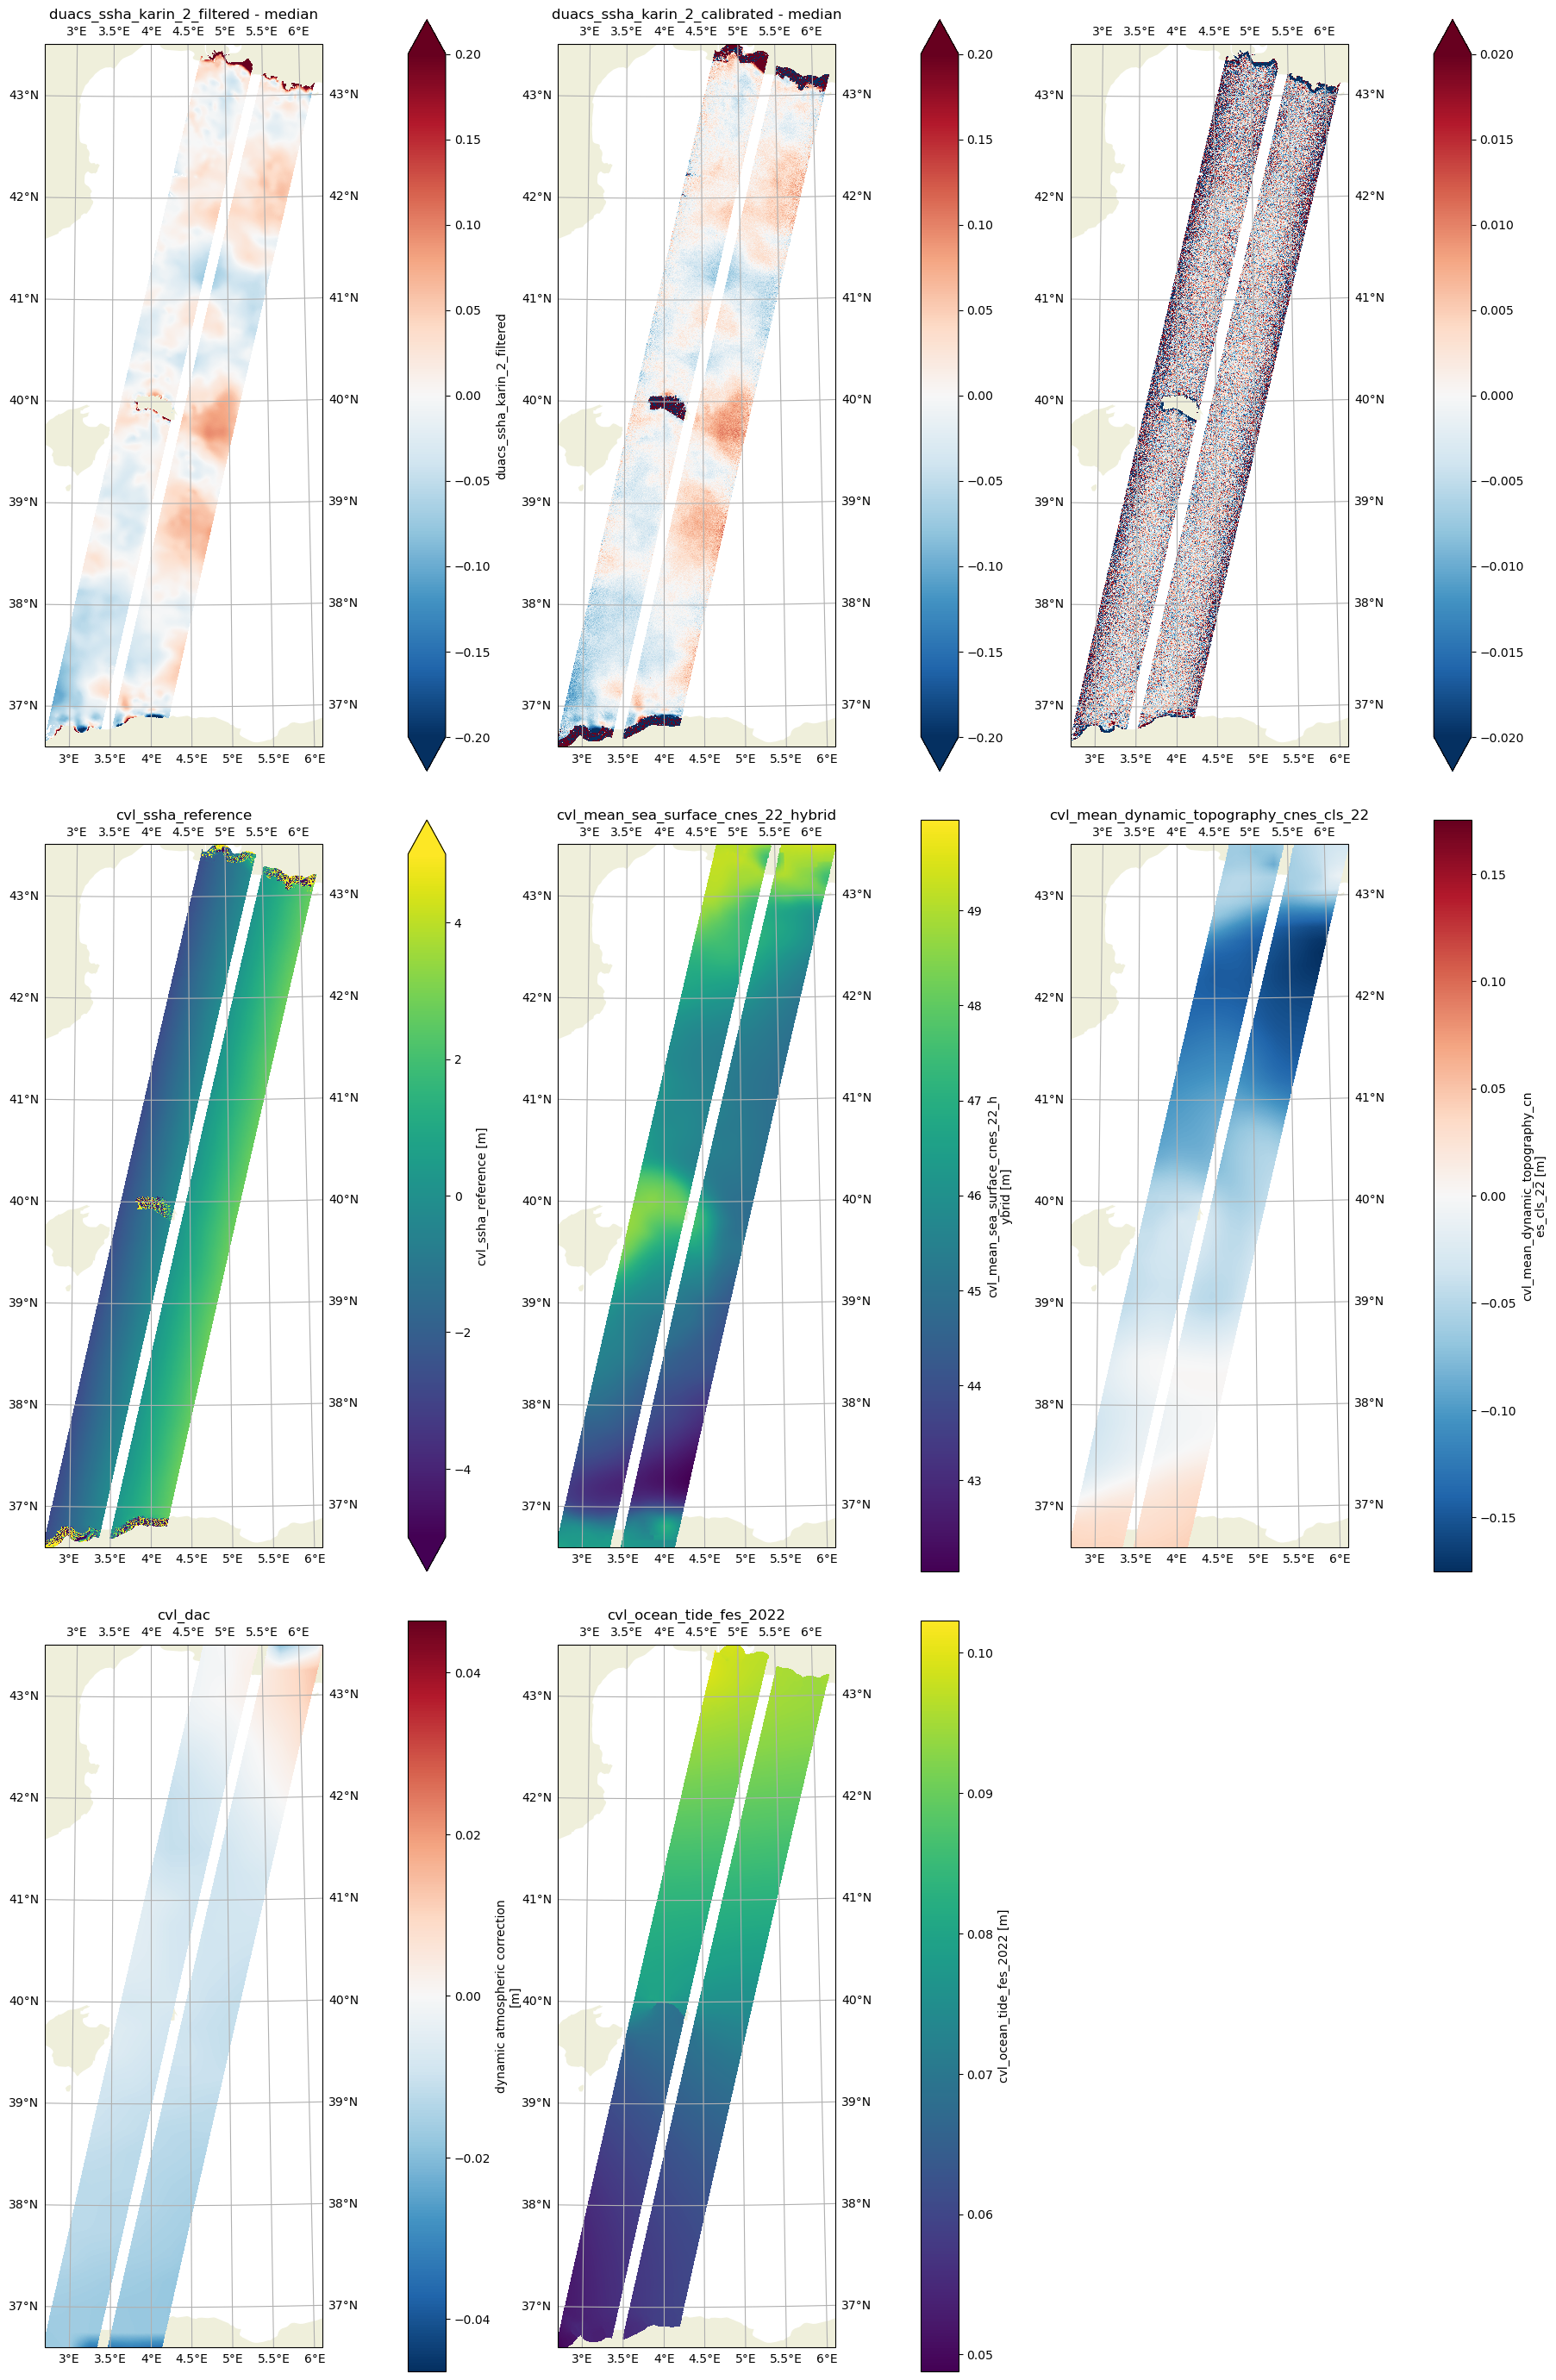

In [79]:
plot_swot(3, 500)

/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


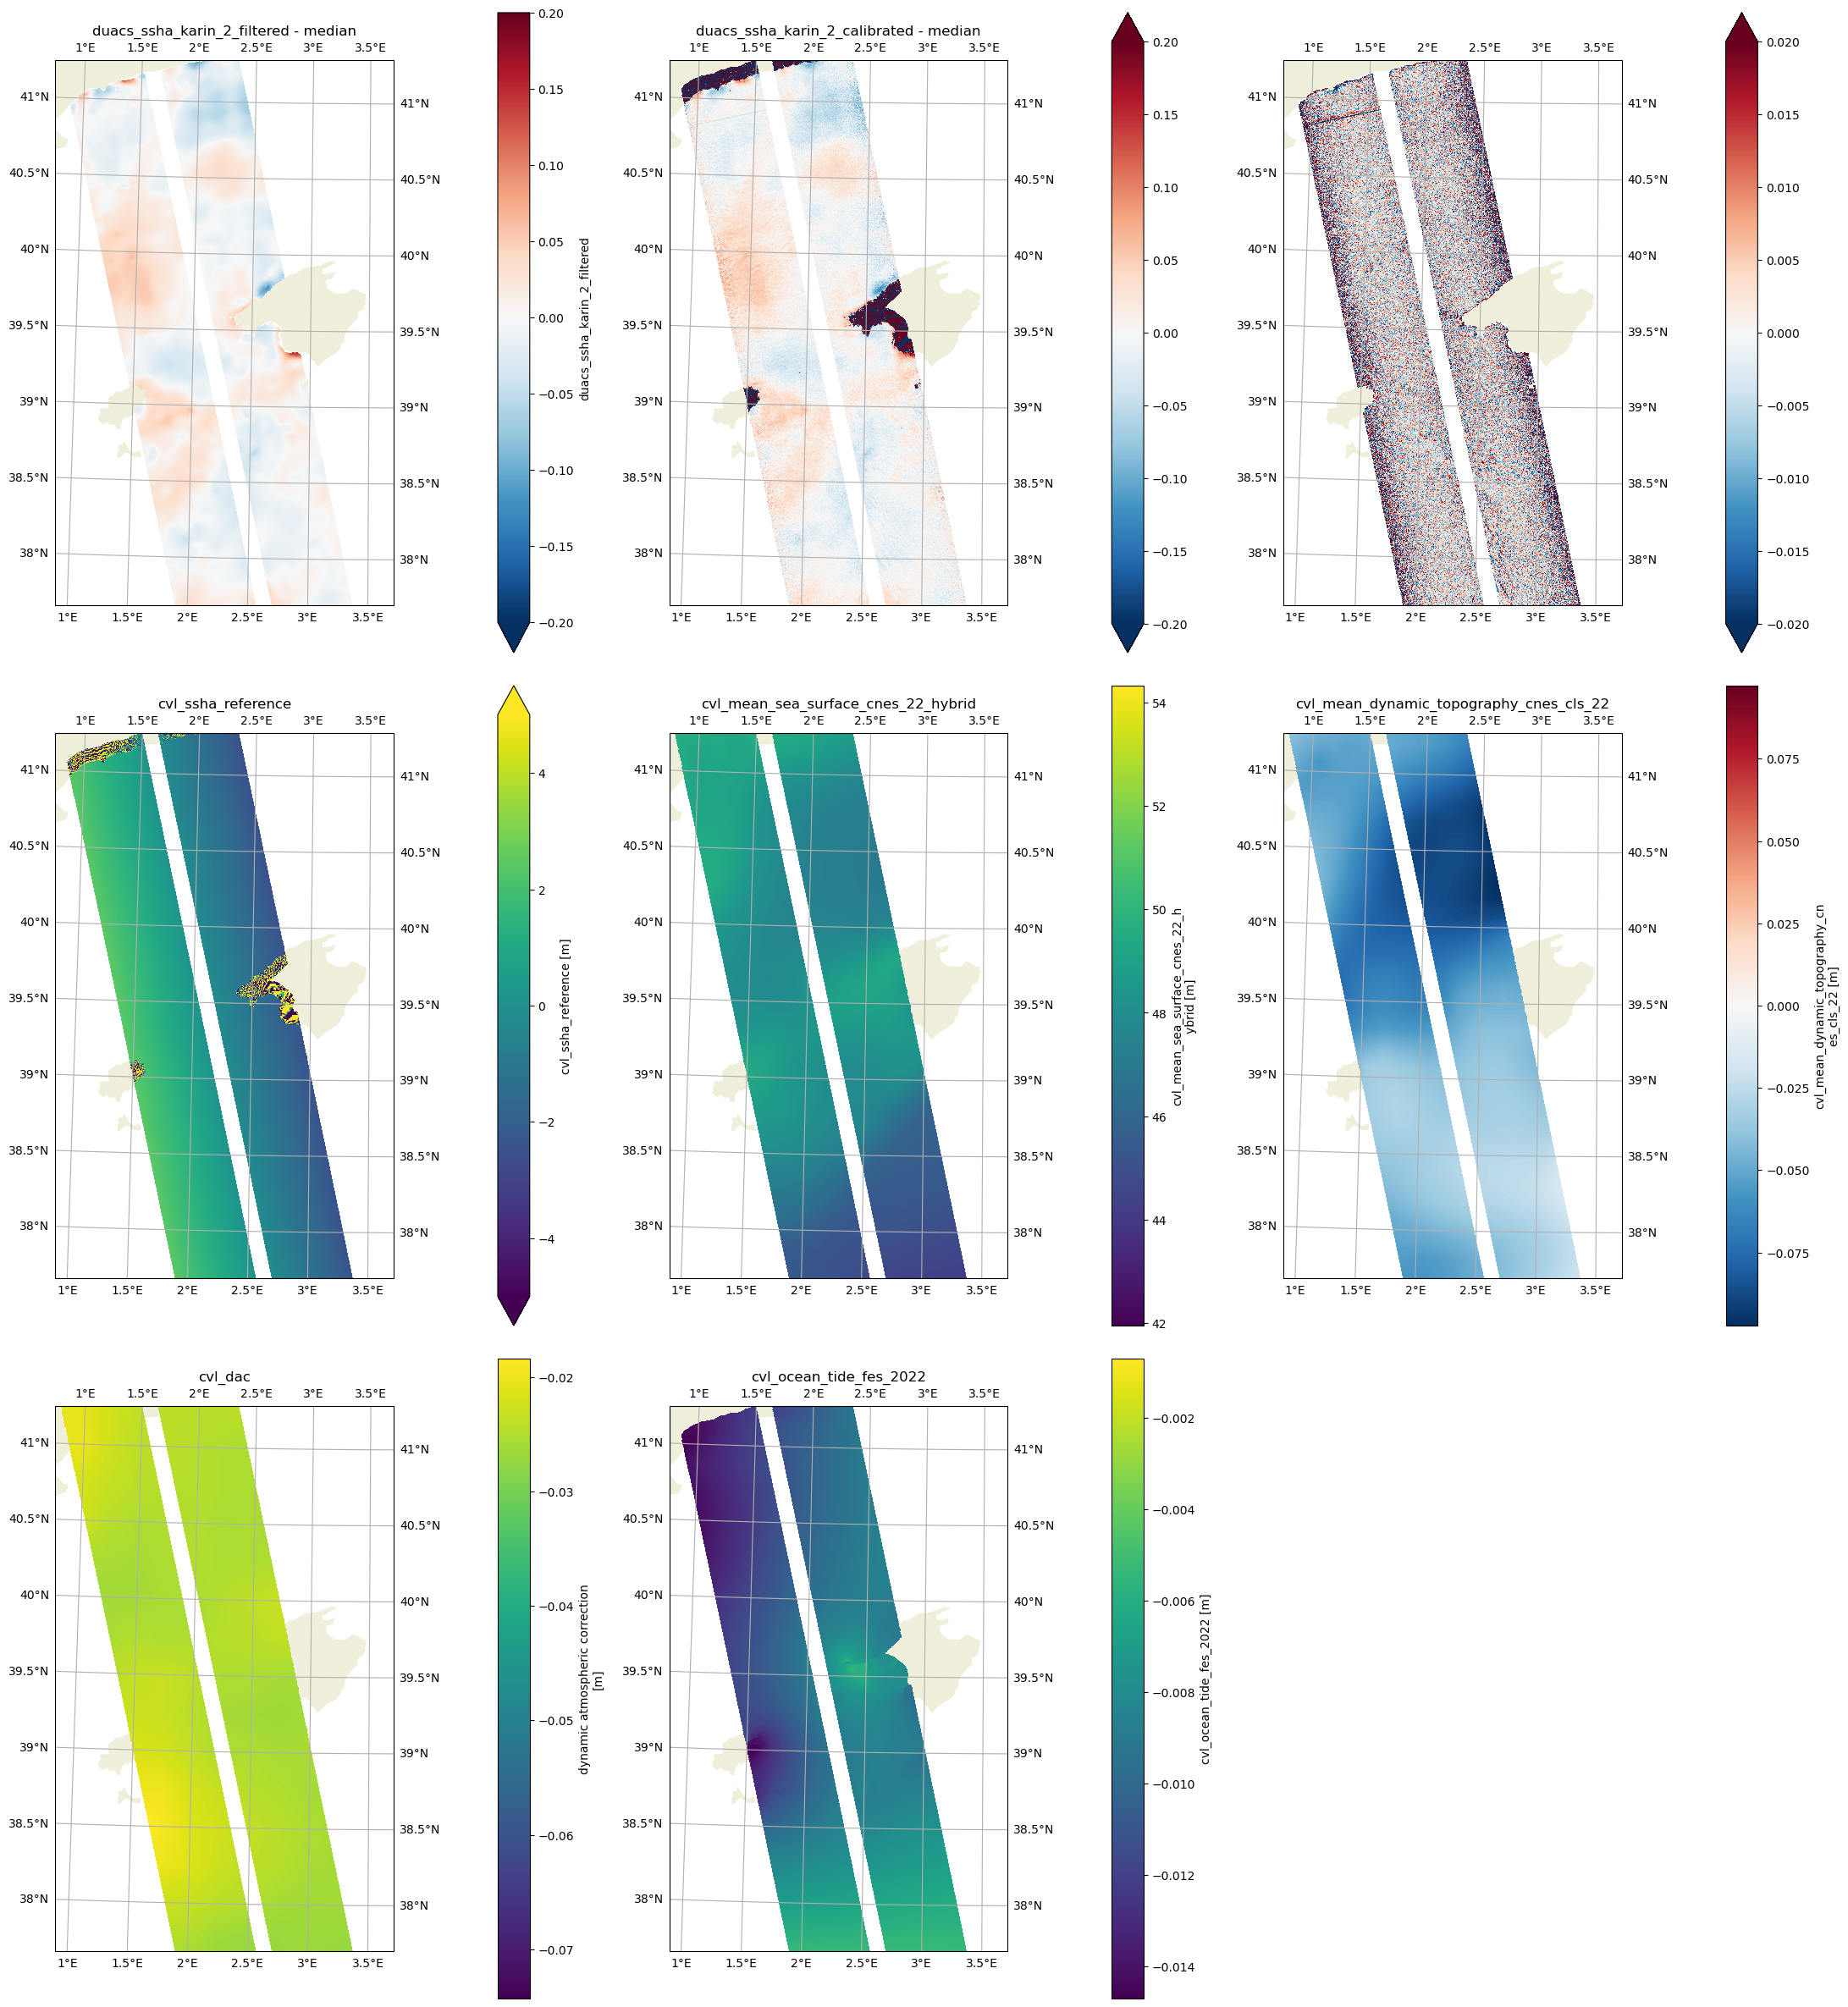

In [80]:
plot_swot(16, 500)